# Steam Games Analysis

What drives a game's reach on Steam, and can it be predicted before launch?

This notebook works through a catalog of ~140,000 Steam games:

1. **Cleaning** the raw export, which turns out to carry several inconsistent schemas
2. **Feature engineering** from the catalog metadata
3. **EDA** on what correlates with reach and reception
4. **Modelling** a game's estimated-owners bucket from information available *before* launch

Source: `steam_games.csv` (~927MB raw).

In [ ]:
import json
import os
import re

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

RAW_CSV = "../steam_games.csv"
PROCESSED_PARQUET = "../data/processed/games.parquet"
sns.set_theme(style="whitegrid")

## 1. First look at the raw data

The raw file is ~927MB, so we start with a 5-row preview rather than loading all of it.

In [ ]:
preview = pd.read_csv(RAW_CSV, nrows=5)
preview

In [ ]:
preview.dtypes

`genres`, `categories`, `tags`, `developers` and `publishers` all come back as strings. Their values *look* like lists — `["Action", "Indie"]` — but pandas has no reason to parse them, so they stay text for now. Section 3 handles that.

## 2. Loading the full catalog

Most of the raw file's bulk is text and URLs we will never model on: full game descriptions, screenshot and video links, support emails. Passing `usecols` means pandas' parser skips those columns entirely rather than loading and then discarding them.

In [ ]:
all_columns = pd.read_csv(RAW_CSV, nrows=0).columns.tolist()

drop_columns = [
    "about_the_game", "detailed_description", "notes", "header_image",
    "screenshots", "movies", "website", "support_url", "support_email",
    "metacritic_url",
]

usecols = [c for c in all_columns if c not in drop_columns]

# low_memory=False reads the file in a single pass. Besides avoiding pandas'
# chunked dtype guessing, it sidesteps a bug in pandas 3.0.5 that raises an
# IndexError while building the mixed-dtype warning for this file.
df = pd.read_csv(RAW_CSV, usecols=usecols, low_memory=False)

print(df.shape)
df.info(memory_usage="deep")

## 3. Cleaning: four inconsistent schemas in one file

The list-like columns are not stored consistently across rows. Each of the issues below surfaced only as a downstream error, traced back to the offending value — none are visible in the first few rows:

| Issue | Example | Rows affected | Handling |
| --- | --- | --- | --- |
| A single value stored as a bare string instead of a JSON array | `supported_languages` = `English` rather than `["English"]` | few | wrap in a one-item list |
| Genres/categories stored as objects rather than names | `[{"id": "4", "description": "Casual"}, ...]` | few | keep the `description` value |
| Tags stored as a name → vote-count mapping instead of a list | `{"Indie": 131, "Action": 126, ...}` | ~23,500 | keep the keys |
| Platform flags mixing booleans with missing values | `windows` ∈ {`True`, `False`, `NaN`} | 15 | treat missing as `False` |

The tag vote counts are richer than what the other ~116,000 rows carry, but they cannot be used consistently across the dataset, so only the tag names are kept.

**Missing-value semantics.** A missing list is treated as "nothing listed" (`[]`) rather than "unknown", because for these columns the two amount to the same thing: a game with no `full_audio_languages` entry has no recorded full audio support. `description_length` is handled differently — see section 5.

In [ ]:
parse_columns = [
    "genres", "categories", "tags", "developers", "publishers",
    "supported_languages", "full_audio_languages",
]


def parse_list(value):
    """Parse a JSON-encoded list cell, tolerating the schema variations above."""
    if isinstance(value, (list, dict)):
        return value  # already parsed; keeps the cell safe to re-run
    if pd.isna(value) or value == "":
        return []
    try:
        return json.loads(value)
    except json.JSONDecodeError:
        return [value]  # a bare string, e.g. supported_languages = "English"


def normalize_items(value):
    """Reduce a parsed cell to a flat list of names, whatever shape it arrived in."""
    if isinstance(value, dict):
        return list(value.keys())  # tags stored as name -> vote count
    return [
        item.get("description", str(item)) if isinstance(item, dict) else item
        for item in value
    ]


for col in parse_columns:
    df[col] = df[col].apply(parse_list).apply(normalize_items)

In [ ]:
# Every parsed column should now hold plain lists of strings, and nothing else.
for col in parse_columns:
    top_level = set(df[col].apply(type))
    assert top_level == {list}, f"{col} holds non-list values: {top_level}"

    elements = {type(item) for lst in df[col] for item in lst}
    assert elements <= {str}, f"{col} holds non-string elements: {elements}"

print("all parsed columns hold lists of strings")

In [ ]:
# Platform flags carry NaN alongside True/False, which forces the column to
# dtype object. Missing is read as "not supported".
for col in ["windows", "mac", "linux"]:
    df[col] = df[col].fillna(False).astype(bool)

df[["windows", "mac", "linux"]].dtypes

## 4. Feature engineering

Every feature here comes from information a developer would know *before* release — how the game is tagged, what it costs, which platforms it ships on. Post-launch signals (reviews, playtime, concurrent players) are deliberately left out of the model; including them would leak the outcome we are trying to predict.

In [ ]:
for col in parse_columns:
    df[col + "_count"] = df[col].apply(len)

# The booleans are cast before summing: adding bool Series directly returns a
# boolean "any platform" result rather than a 0-3 count.
df["platform_count"] = (
    df["windows"].astype(int) + df["mac"].astype(int) + df["linux"].astype(int)
)

df["has_achievements"] = df["achievements"].fillna(0) > 0

df["platform_count"].value_counts().sort_index()

`positive_ratio` is EDA-only — it summarizes post-launch reception, so it is excluded from the model's features (see the leakage note in the modelling section). Dividing by zero reviews would otherwise silently become `NaN` via plain float division; the explicit `np.where` makes that "no signal yet" case visible in the code rather than relying on the reader to know the float-division quirk.

In [ ]:
total_reviews = df["positive"] + df["negative"]
df["positive_ratio"] = np.where(total_reviews > 0, df["positive"] / total_reviews, np.nan)

df["positive_ratio"].isna().sum()
print(((df['positive'] == 0) & (df['negative'] == 0)).sum())

In [ ]:
df["price"].describe()

The median game is \$4.99 and the 75th percentile \$9.99, but the maximum is \$107,500 — an outlier that inflates the standard deviation to ~411. Rather than guess a ceiling that such values would silently fall outside of (landing them in an unbinned `NaN`), the top bucket is left open with `np.inf`.

In [ ]:
# The first edge sits just below zero so that free games (price == 0.00) land
# in their own bucket; pd.cut's intervals exclude the left edge.
df["price_bucket"] = pd.cut(
    df["price"],
    bins=[-0.01, 0, 5, 20, np.inf],
    labels=["free", "budget", "mid", "premium"],
)

df["price_bucket"].value_counts()

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(data=df[df['price'] <= 60], x='price', bins=50, ax=axes[0])
axes[0].set_title('Price distribution (capped at $60)')

sns.histplot(data=df, x='price', bins=50, log_scale=True, ax=axes[1])
axes[1].set_title('Price distribution (log scale, full range)')

plt.tight_layout()

Prices cluster at conventional "charm price" points ($0.99, $4.99, $9.99, $14.99, $19.99, $29.99) rather than spreading smoothly across the range — developers anchor to these tiers by convention, producing a comb-like distribution instead of a bell curve. The tall spike at $0 is free-to-play games. On the log-scale view, the $107,500 outlier from `describe()` is essentially invisible: it is a single row, not a cluster, so it cannot form a visible bar even when the axis is compressed.

## 5. Dates and description length

`errors="coerce"` turns unparseable dates into `NaT` instead of raising — the same defensive stance the list parsing needed.

`description_length` keeps `NaN` where a game has no short description, rather than filling zero: a missing description is of unknown length, not zero length, and collapsing the two would tell the model that ~8,000 games have unusually terse store pages.

In [ ]:
df["release_date"] = pd.to_datetime(df["release_date"], errors="coerce")
df["release_year"] = df["release_date"].dt.year
df["release_month"] = df["release_date"].dt.month

df["description_length"] = df["short_description"].str.len()

df["release_year"].value_counts().sort_index()

In [ ]:
engineered = [
    "genres_count", "categories_count", "tags_count", "supported_languages_count",
    "platform_count", "has_achievements", "price_bucket", "description_length",
    "release_year", "release_month",
]

df[engineered].info()

## 6. The target variable

`estimated_owners` arrives pre-bucketed as ranges, but the raw file encodes them inconsistently — a fifth schema issue, on top of the four in section 3. The same range appears in two different string formats depending on the row, e.g. `"20000 - 50000"` and `"20,000 .. 50,000"` are the same bucket. Left alone, this would fragment 14 real categories into 26, silently hurting any model trained on it.

In [ ]:
def normalize_owners(label):
    """Collapse both raw formats (e.g. "20000 - 50000" and "20,000 .. 50,000")
    into one canonical string per range."""
    numbers = re.findall(r"[\d,]+", label)
    low, high = (int(n.replace(",", "")) for n in numbers)
    return f"{low} - {high}"


df["estimated_owners"] = df["estimated_owners"].apply(normalize_owners)

In [ ]:
owners = df["estimated_owners"].value_counts()
print(owners)
print()
print((owners / len(df) * 100).round(2).astype(str) + "%")

Normalizing collapses 26 raw labels into 14 real buckets — but it also exposes a severe class imbalance: 66.47% of games fall in the lowest bucket (`0 - 20000`), another 15.18% have zero recorded owners, and the top bucket (`100000000 - 200000000`) holds only 4 games out of 139,580. A classifier trained naively here could reach high raw accuracy just by always predicting the majority bucket, so the modelling section evaluates with class-aware metrics (e.g. per-class F1) rather than accuracy alone.

## 7. What genres, tags, and platforms dominate the catalog

`genres` and `tags` are list columns — one game can carry several — so counting how often each value appears requires `explode()`, which turns a row's list into one row per item before counting. Platform support is already boolean, so it just needs summing.

In [ ]:
top_genres = df.explode("genres")["genres"].value_counts().head(10)
top_tags = df.explode("tags")["tags"].value_counts().head(10)
platform_support = df[["windows", "mac", "linux"]].sum()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.barplot(x=top_genres.values, y=top_genres.index, ax=axes[0])
axes[0].set_title("Top 10 genres")
axes[0].set_xlabel("game count")

sns.barplot(x=top_tags.values, y=top_tags.index, ax=axes[1])
axes[1].set_title("Top 10 tags")
axes[1].set_xlabel("game count")

sns.barplot(x=platform_support.values, y=platform_support.index, ax=axes[2])
axes[2].set_title("Platform support")
axes[2].set_xlabel("game count")
axes[2].set_ylabel("platform")

plt.tight_layout()

Indie accounts for 66.5% of all games in the catalog — the single largest genre by a wide margin over the next closest, Casual. This lines up with Steam being flooded with small and solo-developer releases.

"Singleplayer" is the single most common tag, ahead of every genre. This is a supply-side signal, not evidence of player preference: the dataset counts what got built and published, not what players chose to play. Singleplayer games are cheaper and simpler for small Indie teams to build than multiplayer ones — no netcode, matchmaking, or server infrastructure — so the tag's dominance likely reflects what is easy to produce at this scale, not player demand.

The same story shows up in platform support: Windows is essentially universal (~139K games) while Mac (~23K) and Linux (~18K) are a small minority. From section 4's `platform_count` breakdown, 110,512 games support only one platform against just 12,492 that support all three — porting and maintaining builds for multiple platforms is extra engineering effort, so most small teams target only the platform with the largest install base and stop there.

## 8. Price vs. owners bucket

`estimated_owners` is a string column, so pandas has no idea `"20000 - 50000"` comes before `"100000 - 200000"` — a plain alphabetical sort would misorder them. `owner_order` sorts the bucket labels by their actual numeric bounds so every chart in this section displays the buckets correctly, smallest to largest.

In [ ]:
def bucket_bounds(label):
    low, high = label.split(' - ')
    return int(low), int(high)

owner_order = sorted(df['estimated_owners'].unique(), key=bucket_bounds)

plt.figure(figsize=(14, 6))
sns.boxplot(data=df[df['price'] <= 60], x='estimated_owners', y='price', order=owner_order)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

The chart shows that higher owners buckets tend to have a higher median price, which runs counter to the assumption that cheaper games sell more. The flattest boxes at the top of the chart shouldn't be read too literally, though — the `100000000 - 200000000` bucket has only 4 games, `50000000 - 100000000` has 9, and `20000000 - 50000000` has 31. With that few data points, a single unusual value can flatten the whole box, so the apparent "biggest hits are free" pattern likely reflects insufficient data rather than a real trend.

## 9. Platform, genre, and tag counts vs. owners bucket

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.boxplot(data=df, x='estimated_owners', y='platform_count', order=owner_order, ax=axes[0])
axes[0].set_title('Platform count vs owners')
axes[0].tick_params(axis='x', rotation=45)

sns.boxplot(data=df, x='estimated_owners', y='genres_count', order=owner_order, ax=axes[1])
axes[1].set_title('Genre count vs owners')
axes[1].tick_params(axis='x', rotation=45)

sns.boxplot(data=df, x='estimated_owners', y='tags_count', order=owner_order, ax=axes[2])
axes[2].set_title('Tag count vs owners')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()

df['tags_count'].value_counts().sort_index(ascending=False).head(10)

Platform count shows a mild upward trend with owners (median climbs from 1 in the smallest buckets to 2 in most mid/large ones) — bigger, more successful titles can justify the extra engineering cost of porting to Mac and Linux. Genre count stays essentially flat across buckets and doesn't discriminate much on its own.

Tag count is the interesting one: from roughly the `200000 - 500000` bucket upward, the box collapses to a tight sliver sitting almost exactly at 20. That's worth investigating directly rather than trusting the chart at face value.

In [ ]:
df['tags_count'].value_counts().sort_index(ascending=False).head(10)

**A sixth data limitation: `tags_count` is capped, not organic.** 33,494 games sit at *exactly* 20 tags, while every neighboring count is far smaller and roughly smooth (19 → 2,678, 18 → 2,812, 17 → 2,890, ... 21 → only 2). A real, uncapped tagging process wouldn't produce a 12x spike at one specific number followed by an almost total drop-off — that pattern is the signature of a hard cutoff. Whatever scraper produced this Kaggle dataset appears to have only recorded up to 20 tags per game, silently truncating anything beyond that.

This is a different kind of issue than the four schema inconsistencies in section 3: nothing here is malformed, every value is a valid integer, but the column can no longer distinguish games above the cap from each other. A game with 22 real community tags and one with 2,000 both read as `20`. That is exactly why the box plot flattens for popular games: it is not that hit games "settle" around 20 tags, it is that the dataset cannot see past 20 for them. `tags_count` should be treated as a reliable signal only below the cap; above it, its value is an artifact of collection, not of the game's real popularity.

In [ ]:
comparison = pd.crosstab(df['estimated_owners'], df['price_status'], normalize='index') * 100
comparison = comparison.reindex(owner_order)
comparison

Free games' share climbs steadily through the middle buckets (roughly 13-17%) and then jumps sharply at the top: 28% at 5-10M owners, 35.5% at 20-50M, 44.4% at 50-100M, and 100% at the very top bucket (100-200M). Games that reach massive scale skew free-to-play far more than the rest of the catalog — removing the purchase barrier is one of the most effective ways to maximize install count.

This also refines a caveat from section 8: the price-vs-owners box plot showed a flat box at $0 for the top bucket, which was attributed there mainly to having only 4 games. This table shows it is not just a small-sample artifact — all 4 of those games are genuinely free. The small sample size still limits how far this should be generalized, but the flat box was accurate, not noise.

In [ ]:
df['price_status'].value_counts()

A third `price_status` value shows up here that hasn't come up yet: `unavailable`, at 4,230 games (~3%). Worth a quick investigation rather than assuming what it means.

In [ ]:
df[df['price_status'] == 'unavailable']['price'].isna().sum()

In [ ]:
pd.crosstab(df['price_status'], df['steam_store_available'])

**A seventh data limitation: `price_status = "unavailable"` doesn't mean what it sounds like.** Two hypotheses, tested and ruled out:

- *"No price was ever recorded"* — false. Only 428 of the 4,230 `unavailable` rows actually have a missing `price`; the rest carry a real value.
- *"Delisted from the store"* — false. 4,215 of the 4,230 still show `steam_store_available = True`.

The most likely remaining explanation is a scraping artifact: whatever process built this Kaggle dataset probably fetched live pricing separately from the rest of a game's metadata, and for these ~3% of games that specific fetch failed or was rate-limited, independent of whether the game's store page itself was reachable. `unavailable` most likely means "pricing could not be confirmed at scrape time," not a real fact about the game. Left as-is in the data (relabeling it "free" or "paid" would be guessing), but worth knowing before drawing conclusions from `price_status` elsewhere.

## 12. Release year trends

Comparing raw `estimated_owners` across release years would be misleading: it is a cumulative count taken at whatever point the dataset was scraped, so an older game has simply had far more time to accumulate owners than a recent one. A 2025 game showing fewer owners than a 2015 game does not necessarily mean it is less successful — it may just not have had time yet. This is a maturity (time-since-release) bias, not evidence about game quality.

To sidestep this, we look at the *share* of each release year's games that land in the lowest owners bucket (`0 - 20000`) rather than raw owner counts — if maturity bias is the main driver, that share should climb for more recent years, since younger games haven't had time to grow out of the lowest bucket yet.

Text(0.5, 0, 'release year')

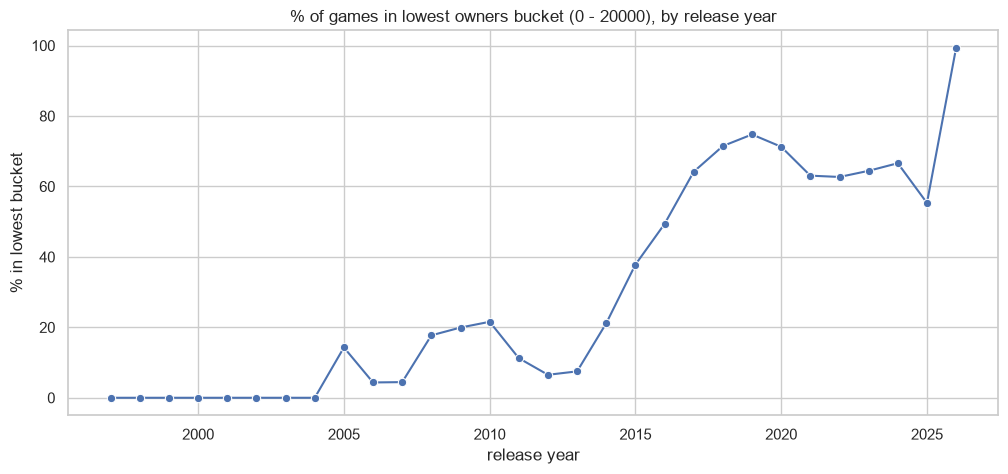

In [29]:
share_lowest = pd.crosstab(df['release_year'], df['estimated_owners'], normalize='index')['0 - 20000'] * 100
share_lowest

plt.figure(figsize=(12, 5))
sns.lineplot(x=share_lowest.index, y=share_lowest.values, marker='o')
plt.title('% of games in lowest owners bucket (0 - 20000), by release year')
plt.ylabel('% in lowest bucket')
plt.xlabel('release year')

The trend broadly confirms maturity bias: the lowest-bucket share climbs from single digits in the early years to 60-70% by the late 2010s, and hits 99.4% for 2026 — this year's releases have barely had any time to accumulate owners at all.

One point breaks the clean story, though: **2025 (55.3%) sits lower than 2024 (66.6%)**, which is backwards if maturity bias were the only thing at play (a younger release year should have a *higher* share in the lowest bucket, not lower) — and 2025 is not a small sample; at 24,687 games it is the single largest release year in the dataset. One available signal was checked as a possible explanation:

In [ ]:
pd.crosstab(df['release_year'], df['steam_spy_available'], normalize='index') * 100

`steam_spy_available` is `True` for every single release year without exception, so it cannot distinguish anything — this test came back uninformative rather than conclusive, ruling nothing in or out. At this point the 2025 dip is left as an **open question**: a real, non-trivial pattern in a well-populated year, with no confirmed explanation available from the columns in this dataset. Two hypotheses remain plausible but unverified — a change in how or when the data was scraped for the newest releases, or some lag in how `estimated_owners` itself gets calculated for very recent games — but neither can be confirmed here. Reported honestly as unresolved rather than forced into a tidy story.

**Implication for modelling.** Because of maturity bias, `release_year` should be expected to correlate strongly with `estimated_owners` for reasons that have nothing to do with a game's actual quality or appeal — it is largely a proxy for "how long has this game had to accumulate owners," not a causal driver of success. It stays in the model as a pre-launch-available feature per the design spec, but this correlation should not be over-interpreted as "newer games are worse."

## 13. Export

Parquet stores the parsed list columns natively, so reloading needs no re-parsing, and it compresses the heavily repeated genre and tag strings well — 927MB of raw CSV lands at roughly 32MB, small enough to commit and to load straight into the dashboard app.

In [ ]:
os.makedirs(os.path.dirname(PROCESSED_PARQUET), exist_ok=True)
df.to_parquet(PROCESSED_PARQUET, index=False)

print(f"{os.path.getsize(PROCESSED_PARQUET) / (1024 * 1024):.1f} MB")